# Coverage plots
## Show that the asymmetric uncertainties gives the correct coverage

### Parameters of interest

In [1]:
std::vector<std::string> Parameters{
    "c1", "c2", "c3", "c4",
    "s1", "s2", "s3", "s4",
    "BF_KKpipi"
};

### Histogram range

In [2]:
std::map<std::string, std::pair<double, double>> Ranges{
    {"c1", {-0.8, 0.1}},
    {"c2", {0.6, 1.0}},
    {"c3", {0.65, 1.05}},
    {"c4", {-1.0, 0.2}},
    {"s1", {-1.5, 1.0}},
    {"s2", {-1.0, 0.6}},
    {"s3", {-0.2, 1.2}},
    {"s4", {-1.8, 1.0}},
    {"BF_KKpipi", {0.0026, 0.0029}}
};

### Uncertainties

In [3]:
std::map<std::string, std::pair<double, double>> Uncertainties{
    {"c1", {0.13, 0.13}},
    {"c2", {0.06, 0.06}},
    {"c3", {0.06, 0.06}},
    {"c4", {0.13, 0.13}},
    {"s1", {0.28, 0.45}},
    {"s2", {0.18, 0.37}},
    {"s3", {0.45, 0.17}},
    {"s4", {0.26, 0.48}},
    {"BF_KKpipi", {0.00005, 0.00005}}
};

### Directory with toys

In [4]:
const std::string ToyDir = "ToyFitResults_Default_230825/";

### Histograms

In [5]:
std::map<std::string, TH1D> Histograms, Histograms_err;
for(const auto &Parameter : Parameters) {
    const double Lower = Ranges[Parameter].first;
    const double Upper = Ranges[Parameter].second;
    Histograms.insert({Parameter, TH1D(Parameter.c_str(), Parameter.c_str(), 50, Lower, Upper)});
    Histograms_err.insert({Parameter, TH1D((Parameter + "_err").c_str(),
                                           (Parameter + "_err").c_str(),
                                           50, 0.0, 0.0)});
}

### Function for loading toy values

In [6]:
void LoadToy(std::size_t ToyNumber) {
    // Filename
    std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/" + ToyDir;
    Filename += "Toy" + std::to_string(ToyNumber) + ".root";
    // Load file
    TFile File(Filename.c_str(), "READ");
    // Check if fit converged properly
    TParameter<int> *Status = nullptr, *CovStatus = nullptr;
    File.GetObject("Status", Status);
    File.GetObject("CovStatus", CovStatus);
    if(Status->GetVal() != 0 || CovStatus->GetVal() != 3) {
        return;
    }
    std::vector<std::string> *VariableNames = nullptr;
    File.GetObject("VariableNames", VariableNames);
    std::vector<double> *FitValues = nullptr;
    File.GetObject("FitValues", FitValues);
    
    std::vector<double> *FitUncertainties = nullptr;
    File.GetObject("FitUncertainties", FitUncertainties);
    for(const auto &Parameter : Parameters) {
        std::size_t i = std::find(VariableNames->begin(),
                                  VariableNames->end(),
                                  Parameter) - VariableNames->begin();
        Histograms[Parameter].Fill((*FitValues)[i]);
        Histograms_err[Parameter].Fill((*FitUncertainties)[i]);
    }
}

### Define asymmetric Gaussian

In [7]:
TF1 AsymmetricGauss("f", "[0]*exp(-0.5*(x - [1])*(x - [1])/([2]*[3] + ([3] - [2])*(x - [1])))", -1.5, 1.5);
AsymmetricGauss.SetParameter(0, 1.0);
AsymmetricGauss.SetParameter(1, 0.0);
AsymmetricGauss.SetParameter(2, 0.5);
AsymmetricGauss.SetParameter(3, 0.5);

### Loop over toys

In [8]:
for(std::size_t i = 0; i < 1000; i++) {
    LoadToy(i);
}

Warning in <TFile::Init>: file /data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/ToyFitResults_Default_230825/Toy14.root probably not closed, trying to recover
Info in <TFile::Recover>: /data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/ToyFitResults_Default_230825/Toy14.root, recovered key TParameter<int>:Status at address 244
Info in <TFile::Recover>: /data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/ToyFitResults_Default_230825/Toy14.root, recovered key TParameter<int>:CovStatus at address 333
Info in <TFile::Recover>: /data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/ToyFitResults_Default_230825/Toy14.root, recovered key TParameter<double>:LL at address 428
Info in <TFile::Recover>: /data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/ToyFitResults_Default_230825/Toy14.root, recovered key vector<string>:VariableNames at address 516
Info in <TFile::Recover>: /data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/ToyFitResults_Default_230825/Toy14.roo

### Plot toy values

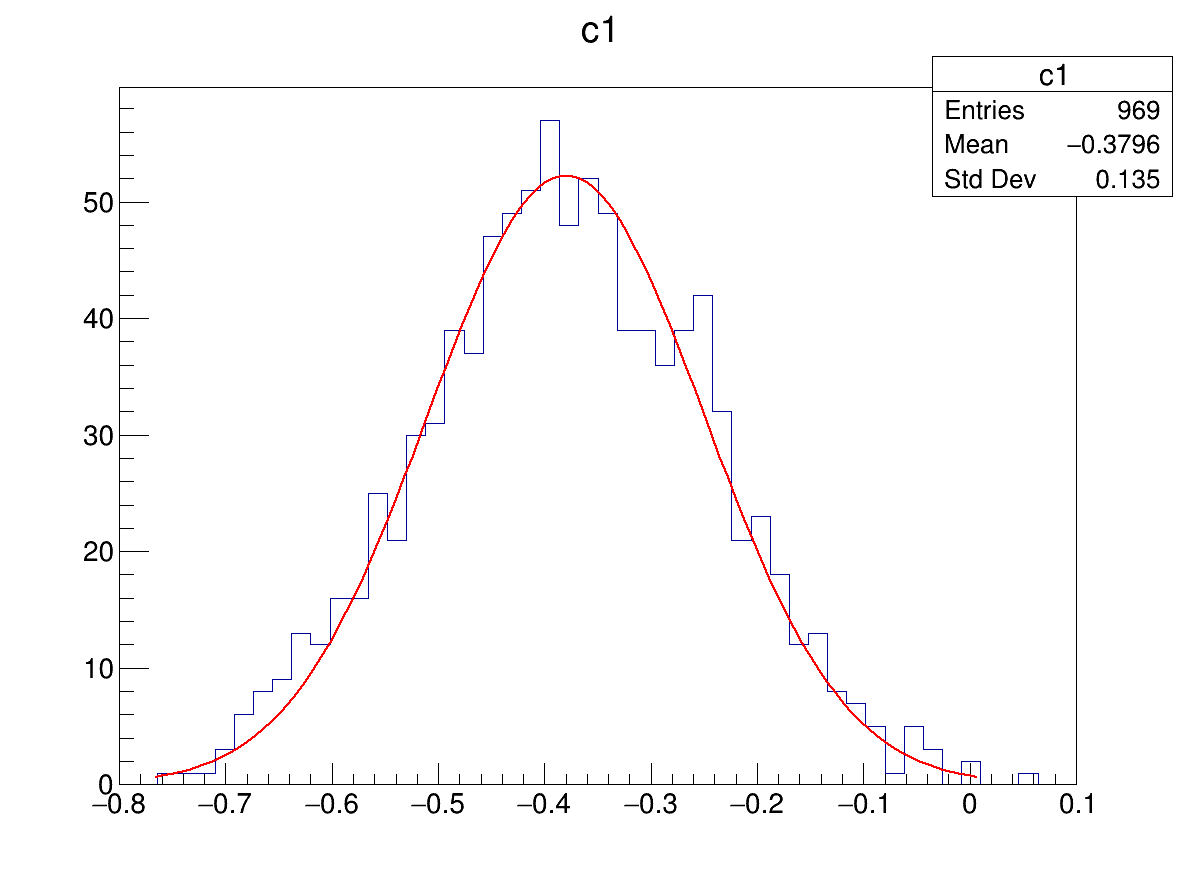

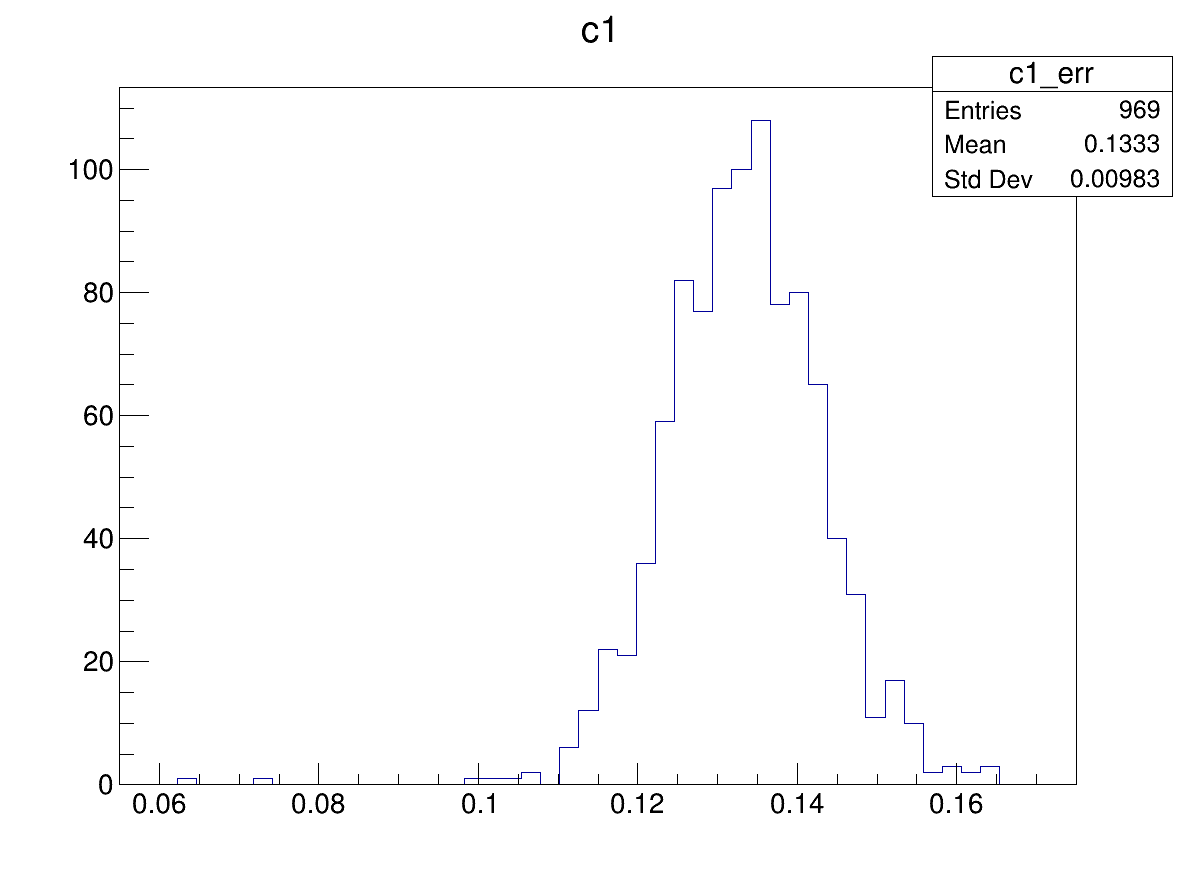

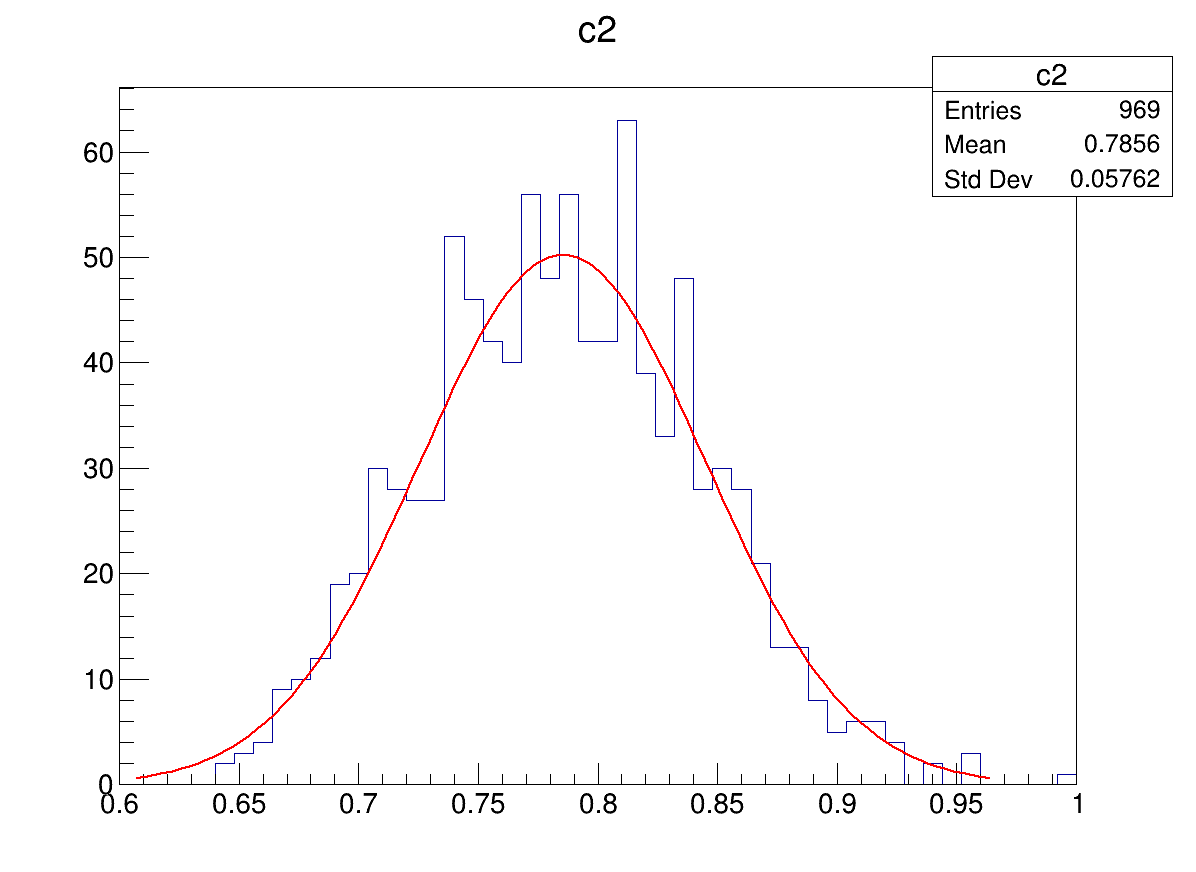

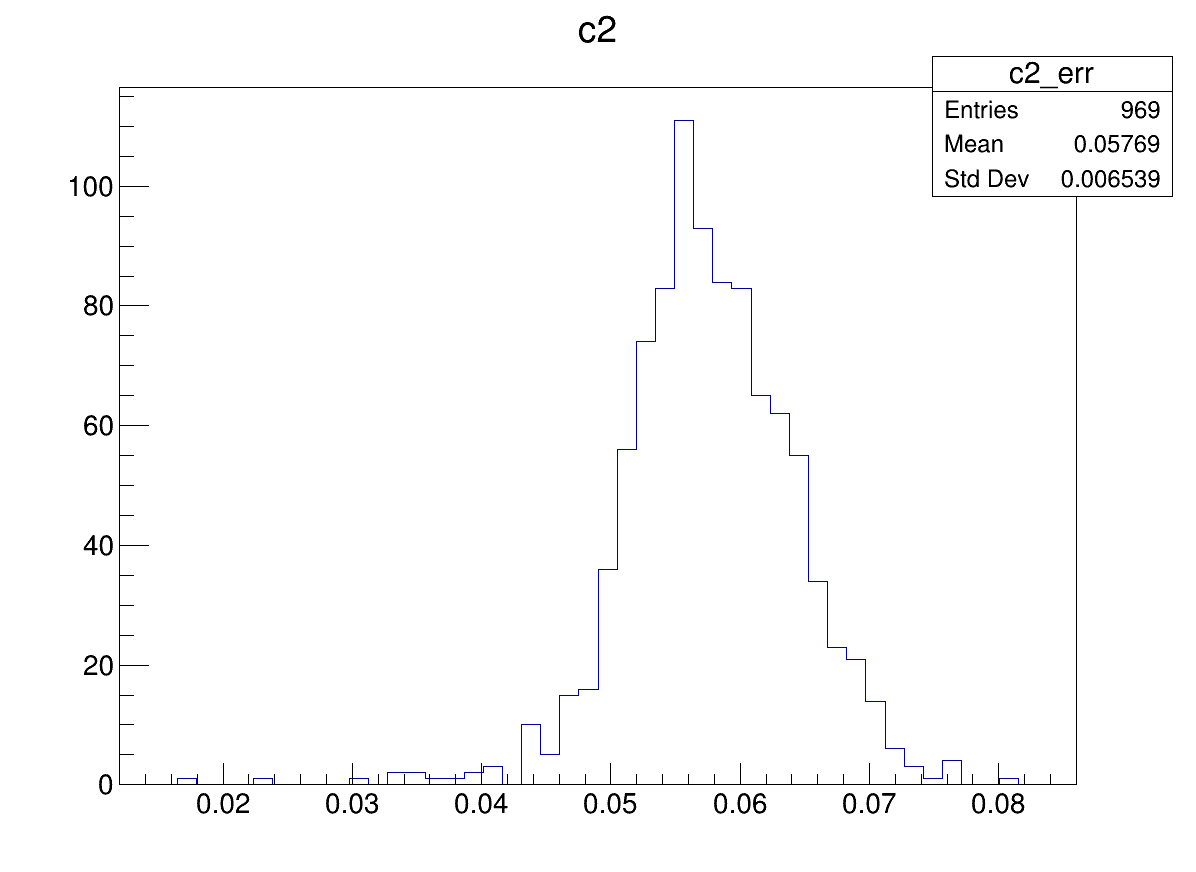

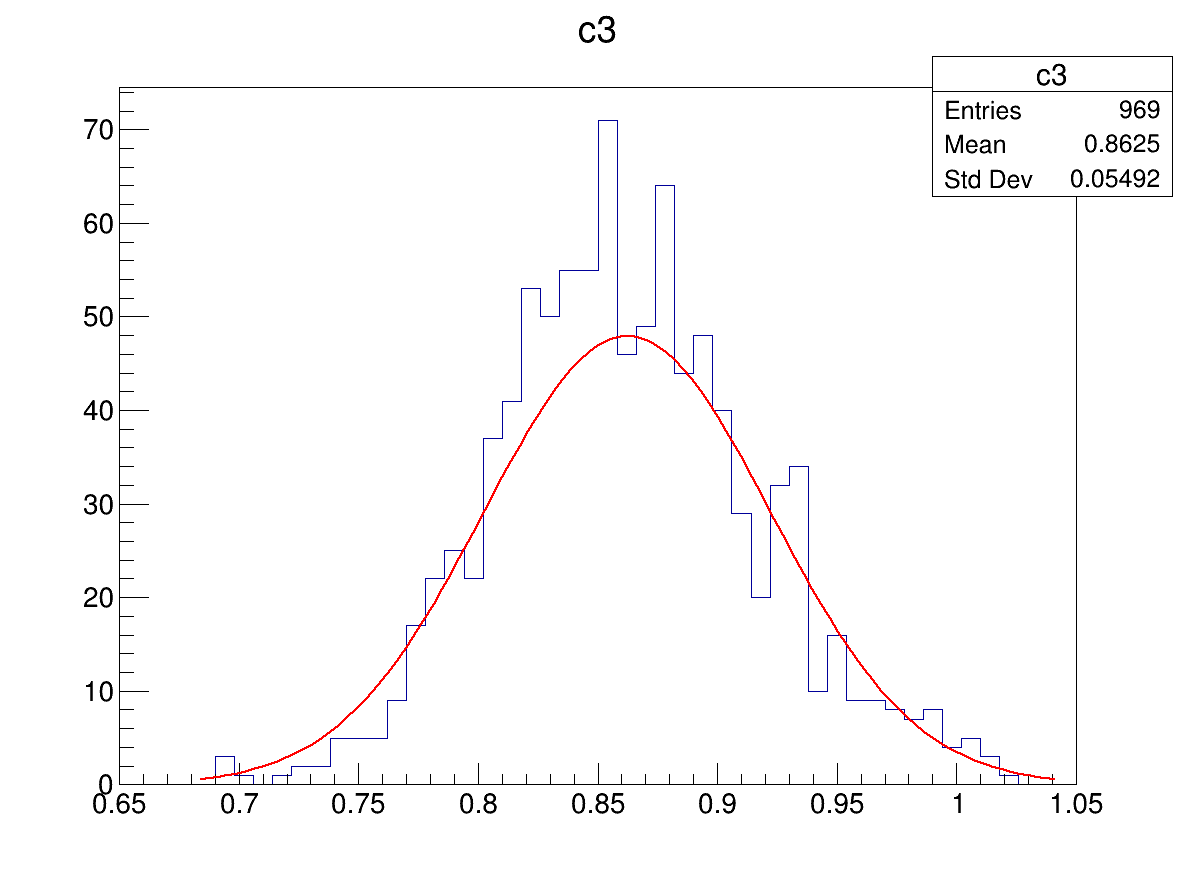

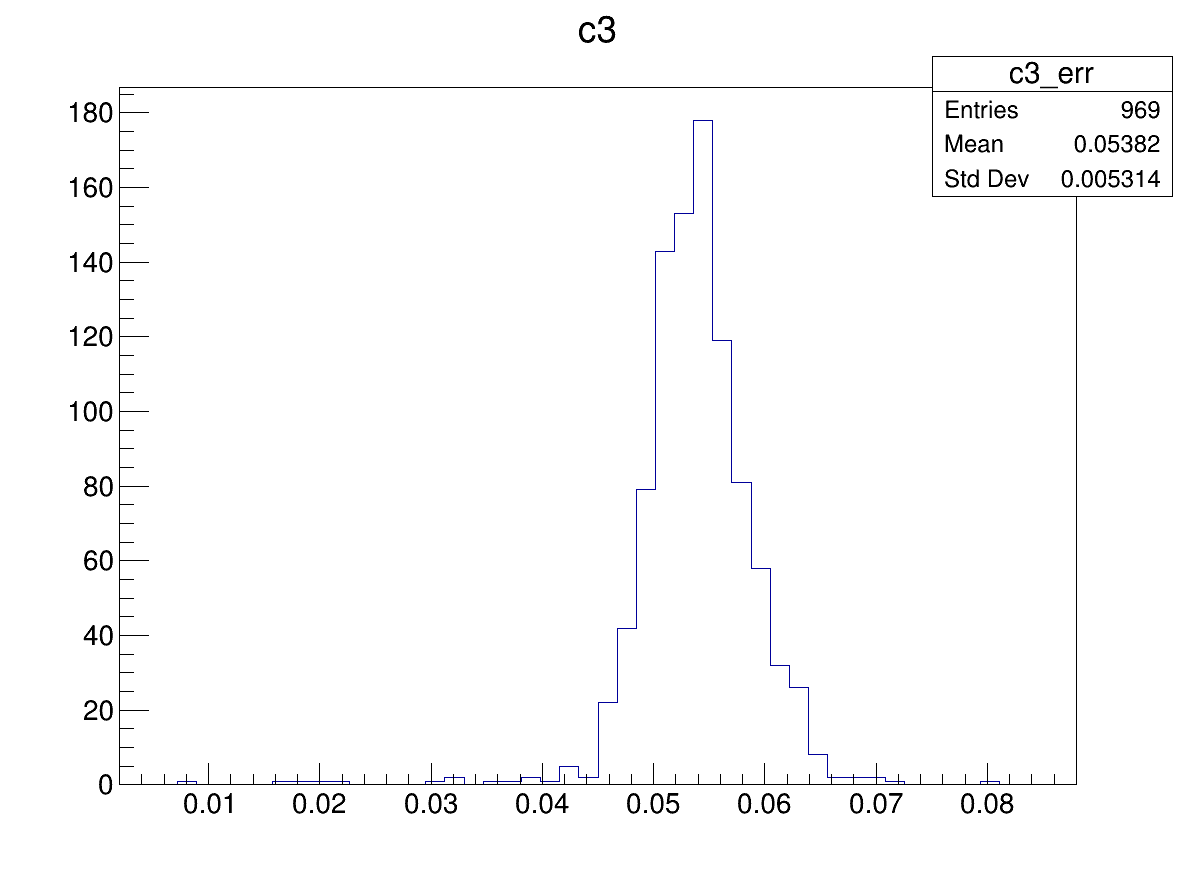

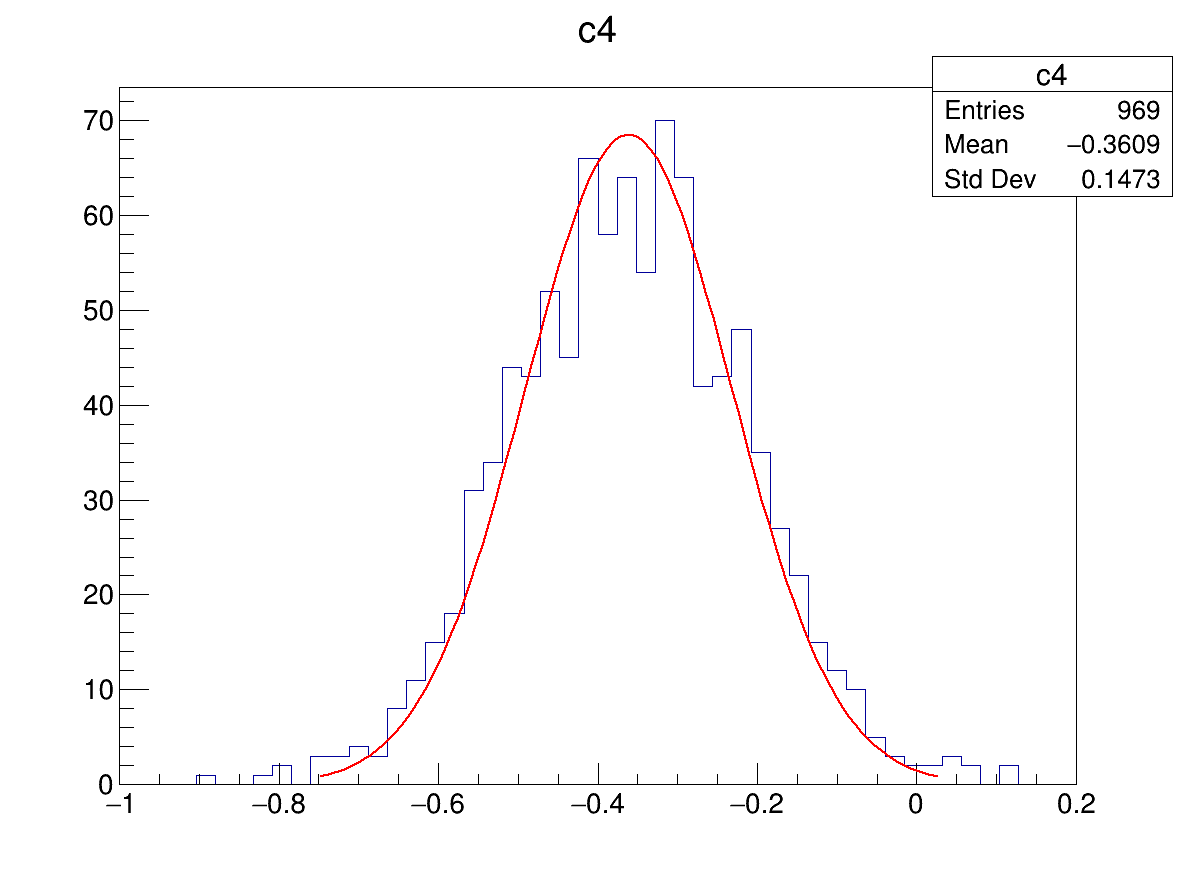

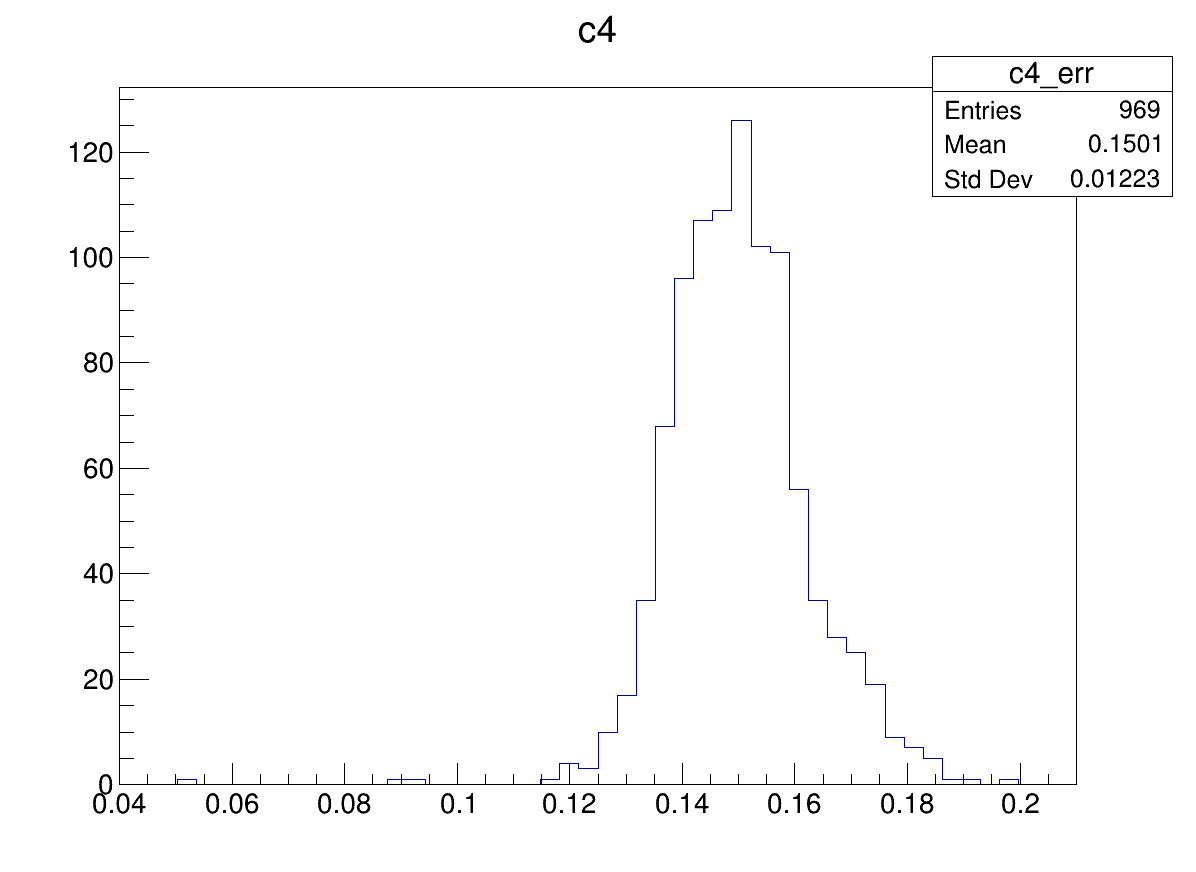

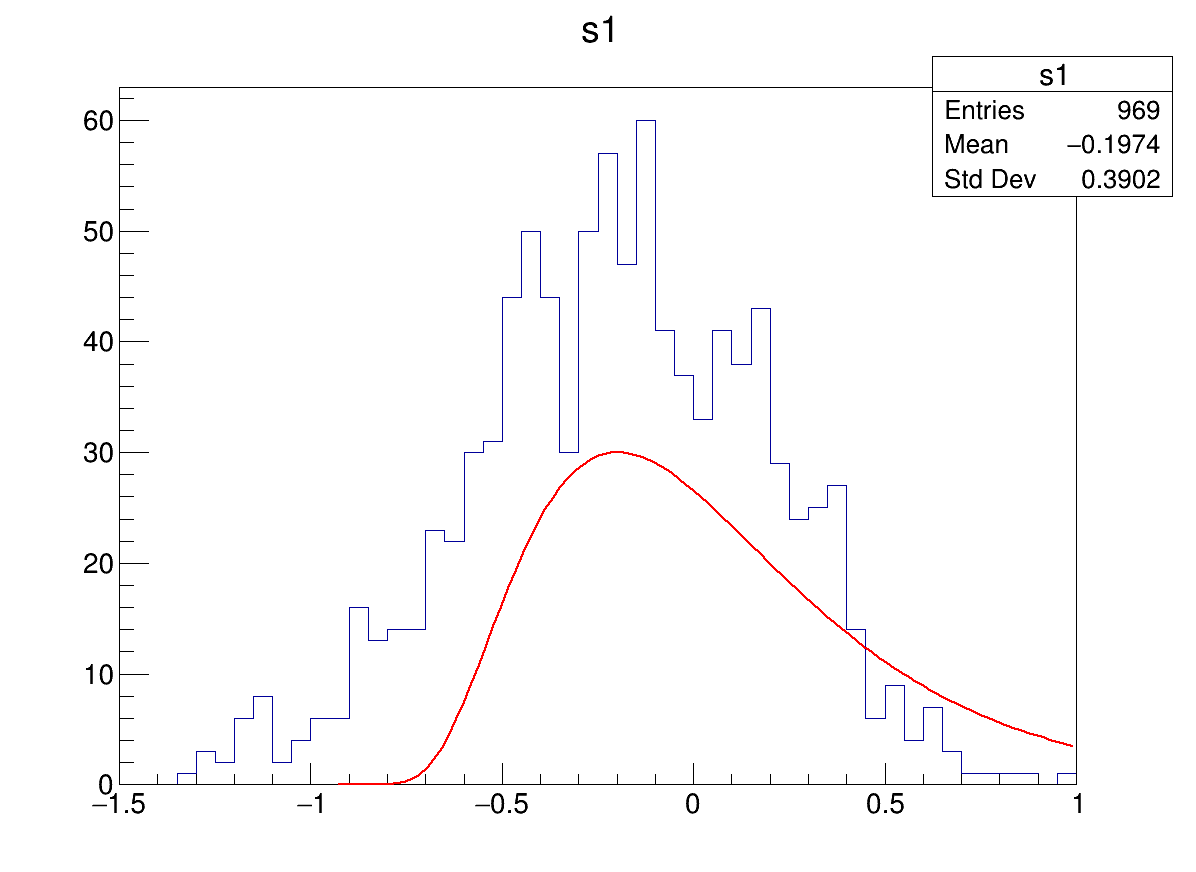

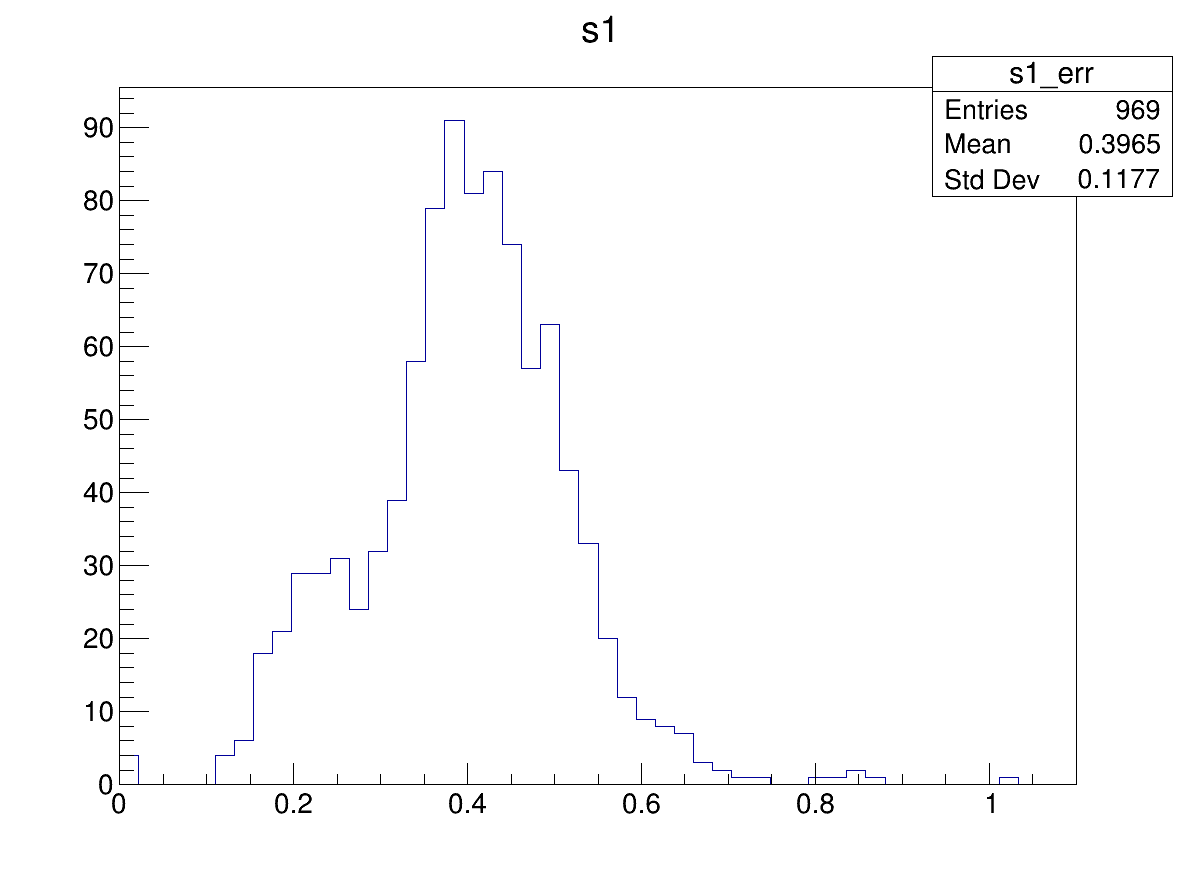

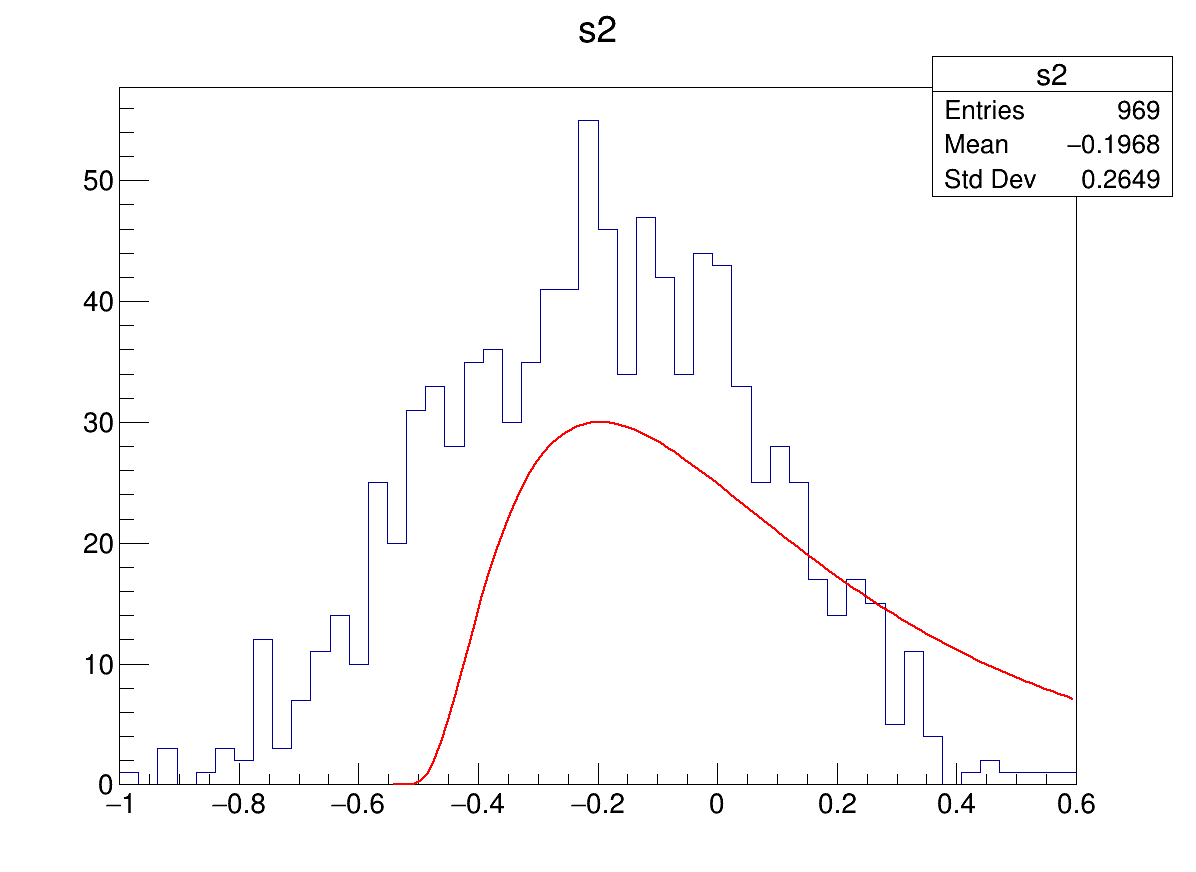

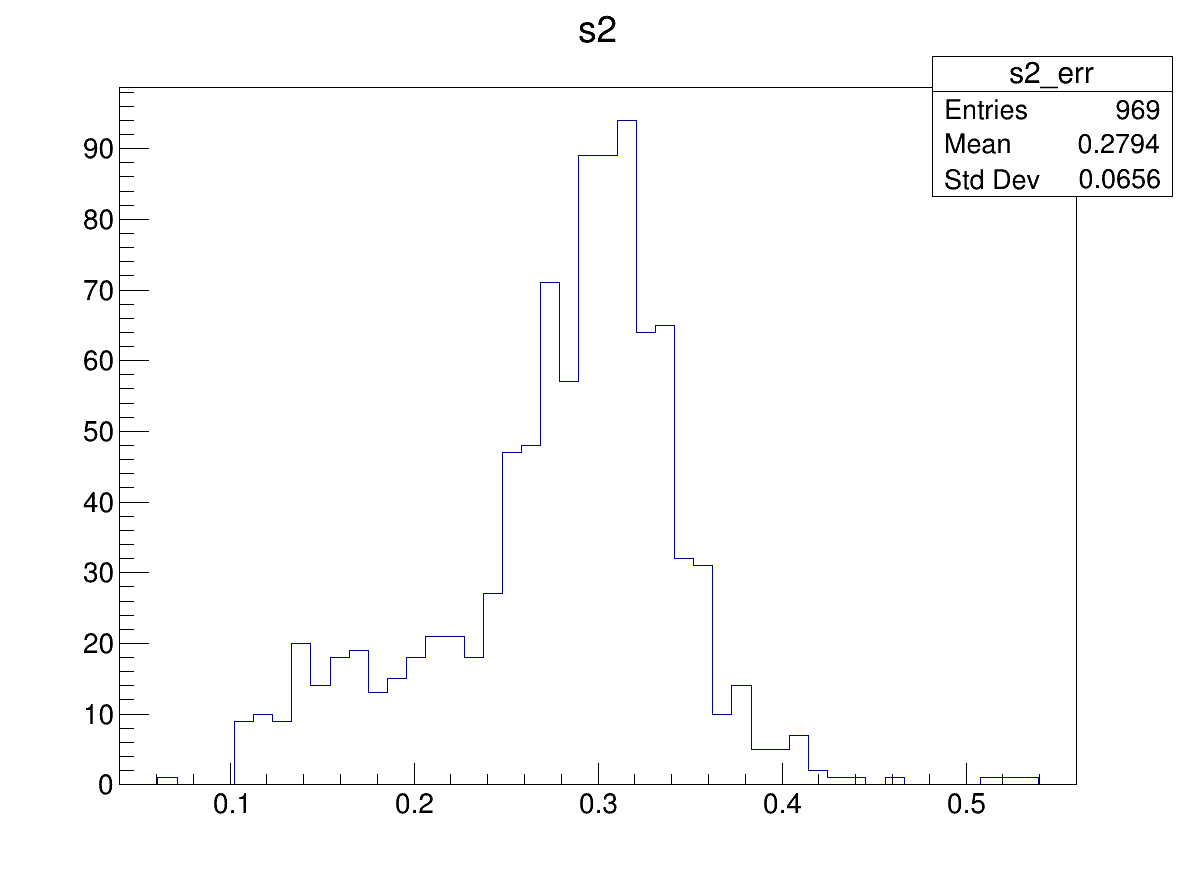

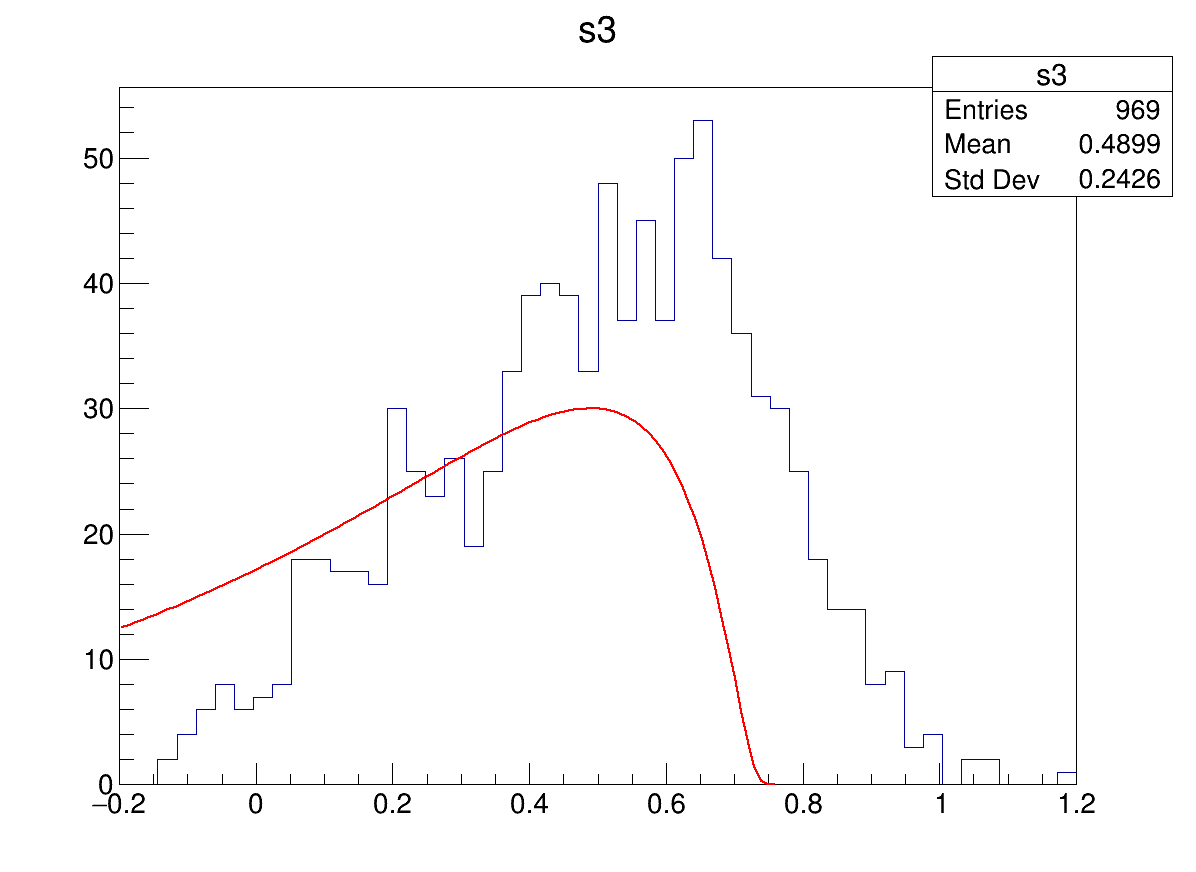

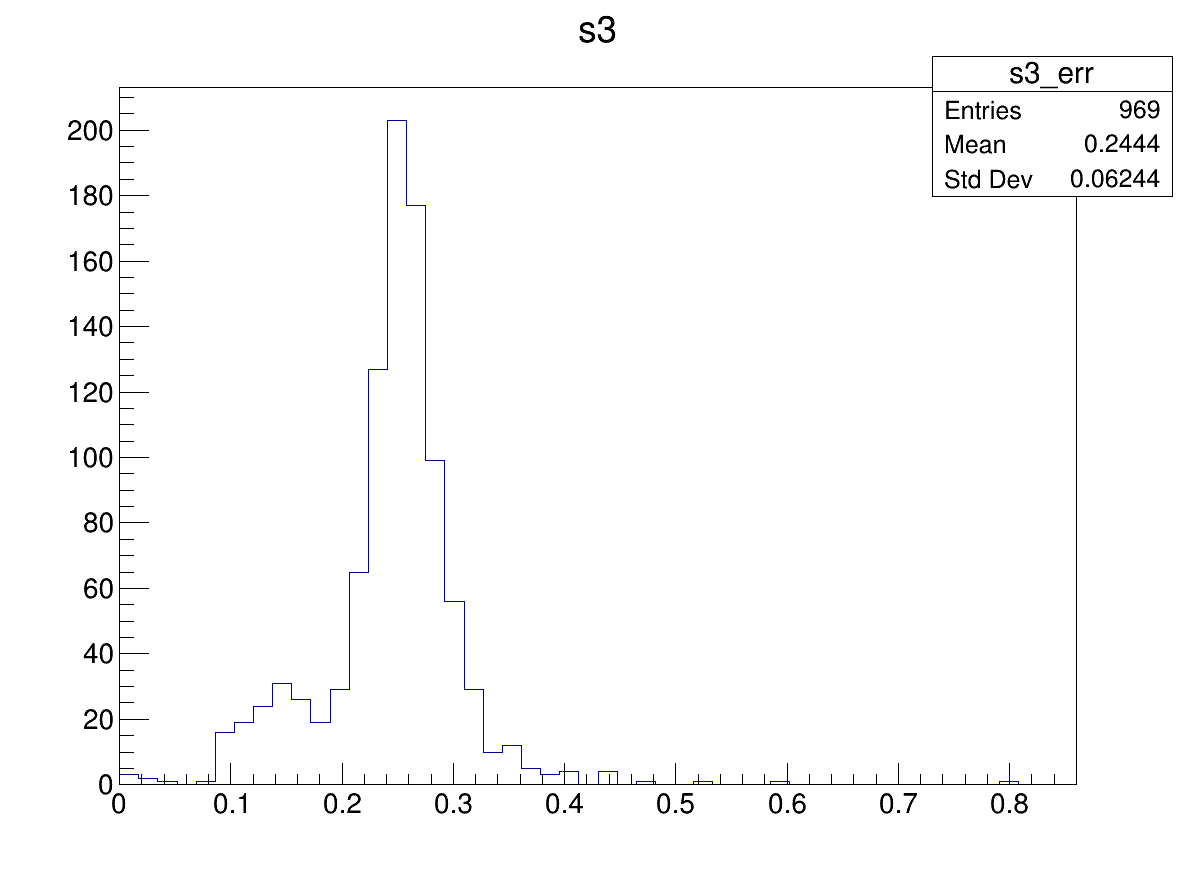

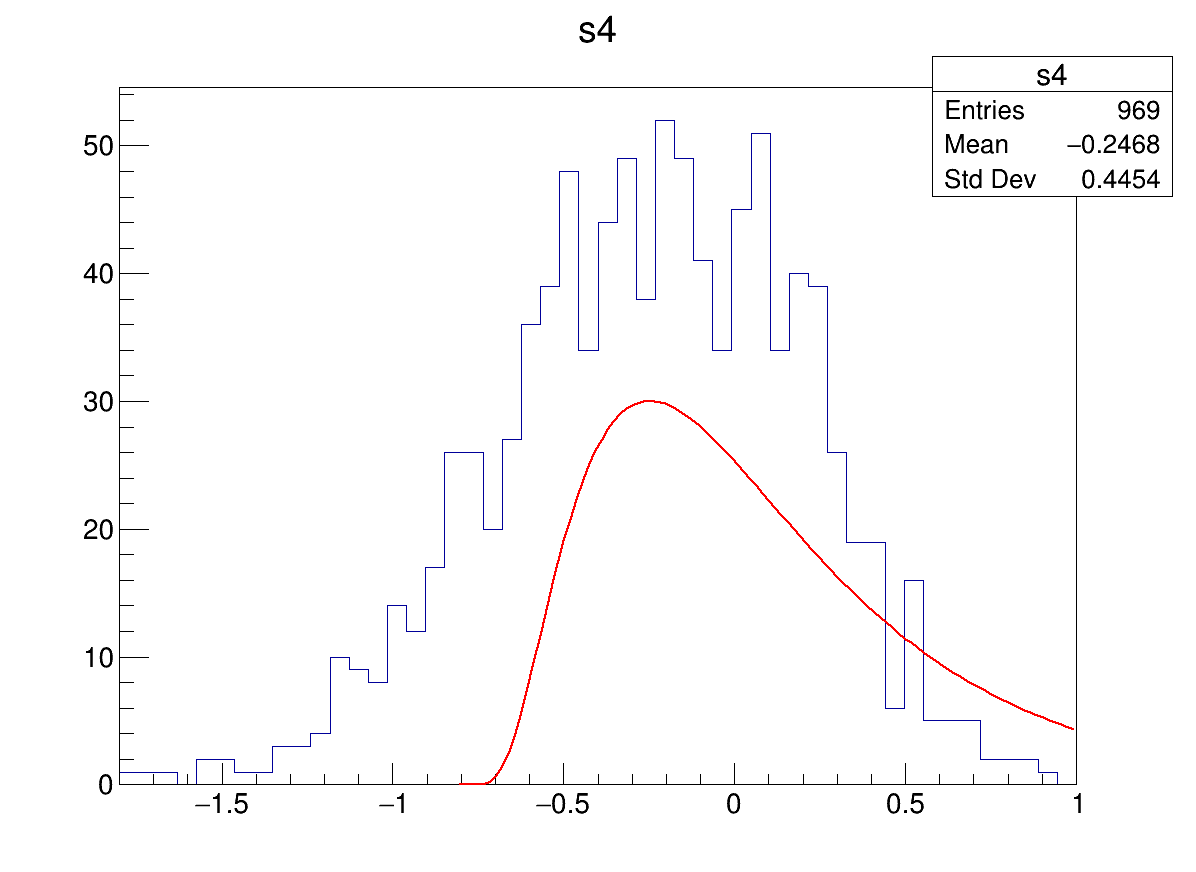

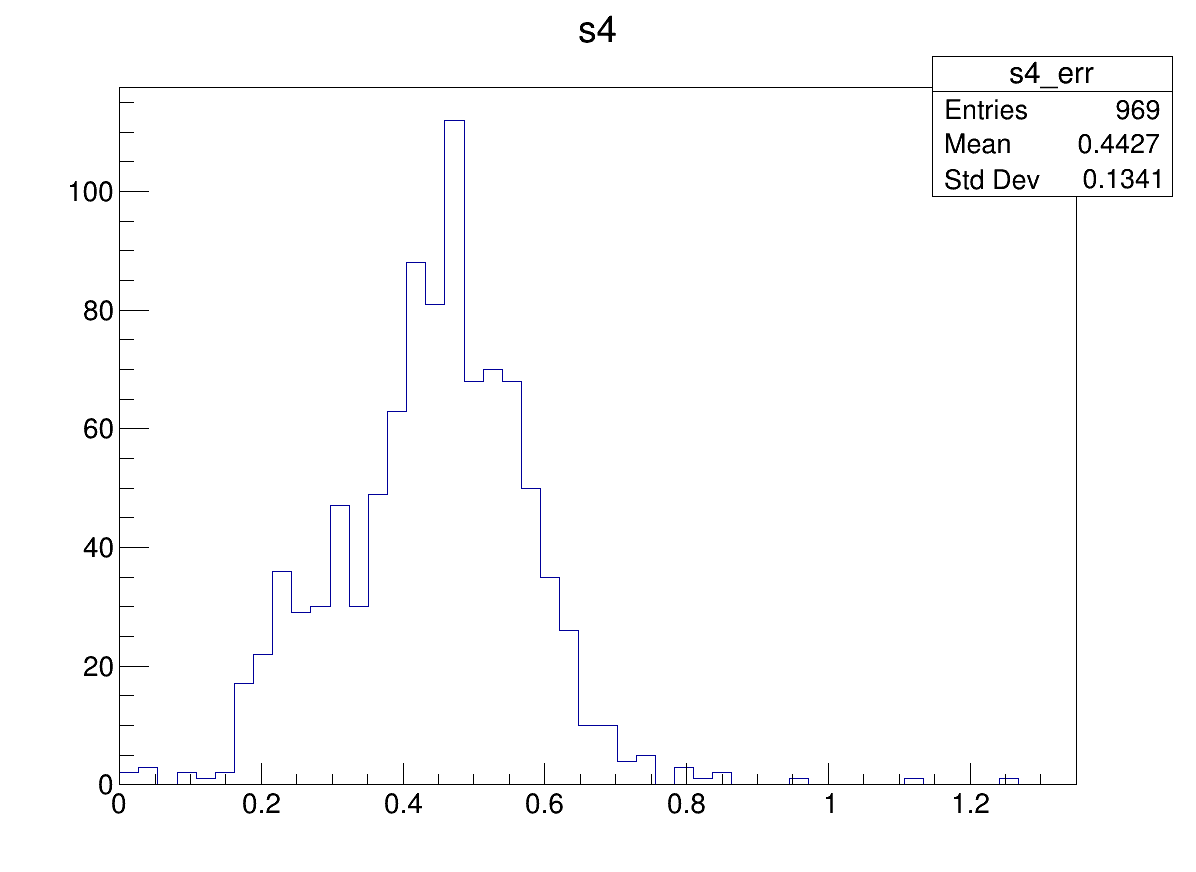

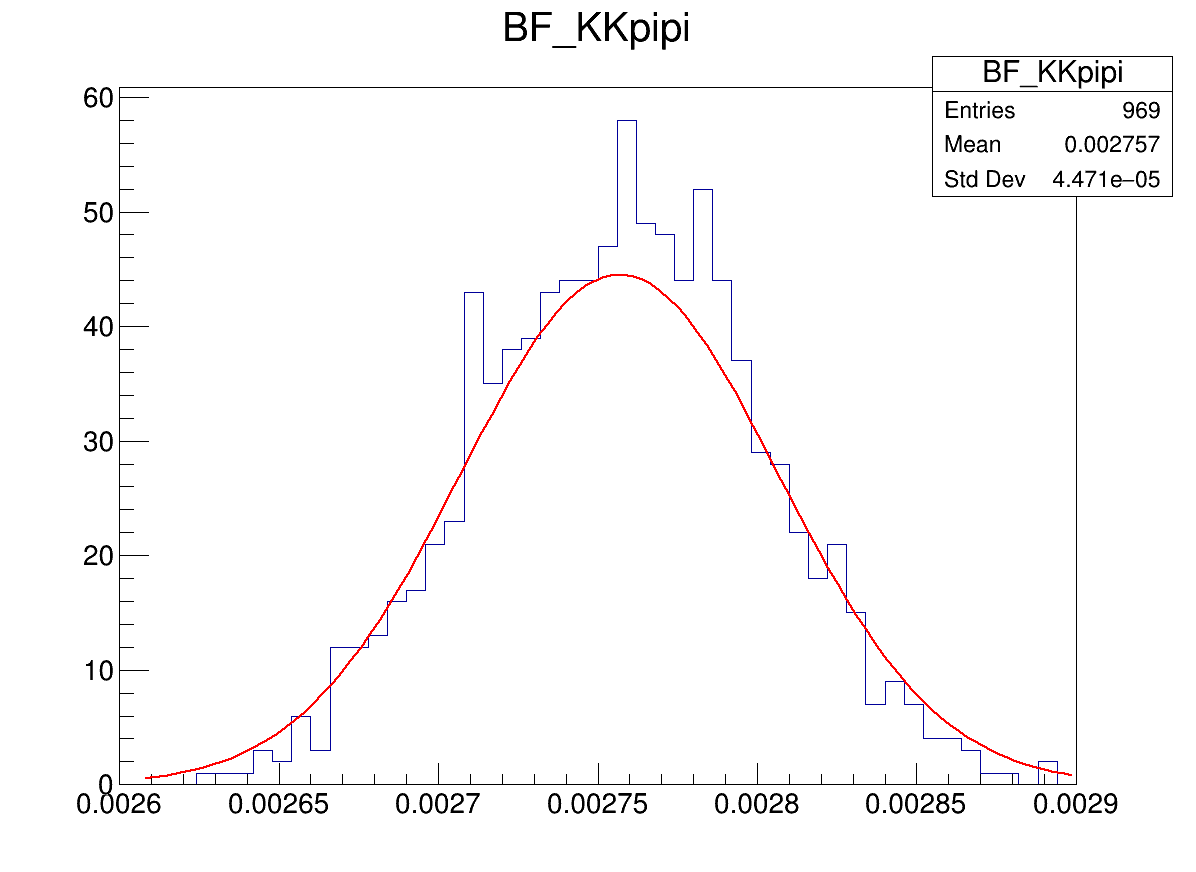

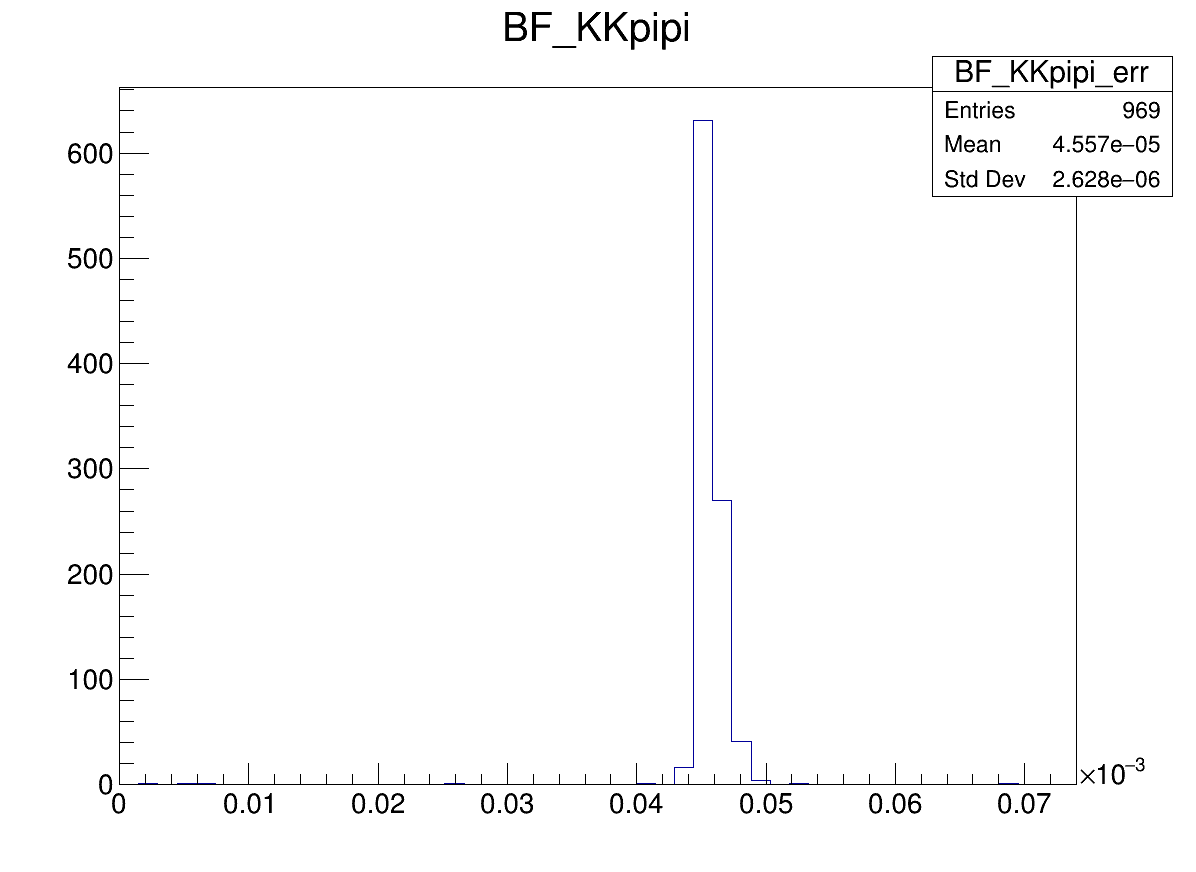

 FCN=26.0465 FROM MIGRAD    STATUS=CONVERGED      12 CALLS          13 TOTAL
                     EDM=1.09281e-14    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           5.22311e+01   1.70182e+00   4.32155e-03  -8.68704e-08
   2  p1          -3.79628e-01     fixed    
   3  p2           1.30000e-01     fixed    
   4  p3           1.30000e-01     fixed    
 FCN=34.4116 FROM MIGRAD    STATUS=CONVERGED      12 CALLS          13 TOTAL
                     EDM=4.23215e-15    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           5.02243e+01   1.64551e+00   4.78128e-03   5.59106e-08
   2  p1           7.85576e-01     fixed    
   3  p2           6.00000e-02     fixed    
   4  p3           6.00000e

In [9]:
for(const auto &Parameter : Parameters) {
    auto *c = new TCanvas((Parameter + "_c").c_str(), "", 1200, 900);
    Histograms[Parameter].SetTitle(Parameter.c_str());
    Histograms[Parameter].Draw("HIST");
    auto AsymmetricGauss2 = static_cast<TF1*>(AsymmetricGauss.Clone());
    AsymmetricGauss2->SetParameter(0, 0.3);
    const double Mean = Histograms[Parameter].GetMean();
    AsymmetricGauss2->FixParameter(1, Mean);
    const double Lower = Uncertainties[Parameter].first;
    AsymmetricGauss2->FixParameter(2, Lower);
    const double Upper = Uncertainties[Parameter].second;
    AsymmetricGauss2->FixParameter(3, Upper);
    if(Lower == Upper) {
        AsymmetricGauss2->SetRange(Mean - 3.0*Lower, Mean + 3.0*Upper);
    } else if(Lower < Upper) {
        AsymmetricGauss2->SetRange(Mean - Upper*Lower/(Upper - Lower), 3.0*Upper);
    } else {
        AsymmetricGauss2->SetRange(Mean - 3.0*Lower, Mean - Upper*Lower/(Upper - Lower));
    }
    if(Parameter[0] != 's') {
        Histograms[Parameter].Fit(AsymmetricGauss2);
    } else {
        AsymmetricGauss2->SetParameter(0, 30.0);
        //Histograms[Parameter].Fit(AsymmetricGauss2);
    }
    AsymmetricGauss2->Draw("L SAME");
    c->Draw();
    auto *c2 = new TCanvas((Parameter + "_err_c").c_str(), "", 1200, 900);
    Histograms_err[Parameter].SetTitle(Parameter.c_str());
    Histograms_err[Parameter].Draw("HIST");
    c2->Draw();
}